In [1]:
import kagglehub
from pathlib import Path
import pandas as pd
import re

/home/guillaume/Workspace/ohw/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading the data

In [2]:
data_dir = Path("./data")
data_dir.mkdir(exist_ok=True)

path = kagglehub.dataset_download(
    "ludmin/billboard",
    output_dir=str(data_dir)
)

In [3]:
hot100 = pd.read_csv('data/hot100.csv')

### Dropping useless columns

In [4]:
hot100 = hot100.drop(columns=['Last Week', 'Peak Position', 'Weeks in Charts'])

In [5]:
hot100

,Date,Song,Artist,Rank,Image URL
0,1958-07-30,Poor Little Fool,Ricky Nelson,1,NaN
1,1958-07-30,Patricia,Perez Prado And His Orchestra,2,NaN
2,1958-07-30,Splish Splash,Bobby Darin,3,NaN
3,1958-07-30,Hard Headed Woman,Elvis Presley With The Jordanaires,4,https://charts-static.billboard.com/img/1958/0...
4,1958-07-30,When,Kalin Twins,5,NaN
...,...,...,...,...,...
355353,2026-09-02,Rubberz,Fenix Flexin,96,https://charts-static.billboard.com/img/2026/0...
355354,2026-09-02,Bet On That,Blake Whiten,97,https://charts-static.billboard.com/img/2025/0...
355355,2026-09-02,Ran To Atlanta,Drake Featuring Future & Molly Santana,98,https://charts-static.billboard.com/img/2009/0...
355356,2026-09-02,National Treasures,Drake,99,https://charts-static.billboard.com/img/2009/0...


In [6]:
hot100.isnull().mean().sort_values(ascending=False)

Image URL    0.349549
Date         0.000000
Song         0.000000
Artist       0.000000
Rank         0.000000
dtype: float64

In [7]:
hot100.shape

(355358, 5)

### Dropping songs higher than top 40

In [8]:
hot100 = hot100[hot100["Rank"] <= 40].reset_index(drop=True)

In [9]:
hot100.shape

(142137, 5)

### creating new columns

In [10]:
hot100["WeeksTop40"] = hot100.groupby(["Song", "Artist"])["Song"].transform("count")

In [11]:
hot100["Artist"] = hot100["Artist"].str.replace('"', '', regex=False)

In [12]:
ONE_ARTIST_WITH_THE = {"Tyler, The Creator"}

def extract_featuring(artist_str: str):
    """
    Returns:
        base_artist: artist string with featuring parts removed
        featuring_part: string like 'feat. X, Y' or '' if none
    """
    s = str(artist_str).strip()
    s = s.strip('"')
    
    featuring_parts = []
    
    # 1) Parenthetical/bracketed featuring/with/etc.
    def extract_paren(m):
        inner = m.group(1)
        # Normalize to 'feat. ...'
        featuring_parts.append(inner)
        return ""  # remove from base
    
    s = re.sub(
        r"\s*[\(\[]\s*(.*?(?:feat\.?|featuring|ft\.?|with|w\/?|duet|co-starring).*?)\s*[\)\]]",
        extract_paren,
        s,
        flags=re.IGNORECASE
    ).strip()
    
    # 2) Inline "Artist feat. X" or "Artist with X", etc.
    inline_match = re.search(
        r"\s+(?:feat\.?|featuring|ft\.?|with|w\/?|duet|co-starring)\s+(.*)",
        s,
        flags=re.IGNORECASE
    )
    if inline_match:
        featuring_parts.append(inline_match.group(1))
        s = s[:inline_match.start()].strip()
    
    base_artist = s.strip()
    
    if not featuring_parts:
        return base_artist, ""
    
    # Combine all featuring parts into one string
    feat_str = ", ".join(featuring_parts)
    feat_str = re.sub(r"\s+", " ", feat_str).strip()
    feat_str = re.sub(r"\s*[,;&]\s*$", "", feat_str)
    
    return base_artist, f"feat. {feat_str}"

def split_artists_raw(artist_str: str):
    s = str(artist_str).strip()
    s = s.strip('"')
    
    if s in ONE_ARTIST_WITH_THE:
        return [s]
    
    # Remove parenthetical/bracketed featuring/with/etc. for splitting purposes
    s_split = re.sub(
        r"\s*[\(\[].*?(?:feat\.?|featuring|ft\.?|with|w\/?|duet|co-starring).*?[\)\]]",
        "",
        s,
        flags=re.IGNORECASE
    ).strip()
    
    s_split = re.sub(r"\s*[\(\[].*?[\)\]]", "", s_split).strip()
    
    s_split = re.sub(
        r"\s+(?:feat\.?|featuring|ft\.?|with|w\/?|duet|co-starring)\s+.*",
        "",
        s_split,
        flags=re.IGNORECASE
    ).strip()
    
    # Normalize collaboration separators to comma
    s_split = re.sub(r"\s*&\s*", ", ", s_split)
    s_split = re.sub(r"\s+[xX×]\s+", ", ", s_split)
    s_split = re.sub(r"\s*\+\s*", ", ", s_split)
    s_split = re.sub(r"\s*/\s*", ", ", s_split)
    
    parts = [p.strip() for p in s_split.split(",") if p.strip()]
    
    cleaned = []
    for p in parts:
        p = p.strip()
        p = re.sub(r"^[&,\s]+", "", p)
        p = re.sub(r"[&,\s]+$", "", p)
        p = p.strip()
        if p:
            cleaned.append(p)
    
    return cleaned if cleaned else [s]

# 1) Extract featuring info and adjust song titles
featuring_info = hot100["Artist"].apply(extract_featuring)
hot100["BaseArtist"] = featuring_info.apply(lambda x: x[0])
featuring_suffix = featuring_info.apply(lambda x: x[1])

# Append featuring to song title where present
mask_feat = featuring_suffix != ""
hot100.loc[mask_feat, "Song"] = (
    hot100.loc[mask_feat, "Song"] + " (" + featuring_suffix.loc[mask_feat] + ")"
)

# 2) Split artists using the cleaned BaseArtist
hot100["ArtistList"] = hot100["BaseArtist"].apply(split_artists_raw)

# 3) Explode
hot100_exploded = hot100.explode("ArtistList").reset_index(drop=True)

if "Artist" in hot100_exploded.columns:
    hot100_exploded = hot100_exploded.drop(columns=["Artist"])

hot100_exploded = hot100_exploded.rename(columns={"ArtistList": "Artist"})

hot100_exploded["Artist"] = (
    hot100_exploded["Artist"]
    .astype(str)
    .str.strip()
    .str.replace(r"^[&,\s]+", "", regex=True)
    .str.replace(r"[&,\s]+$", "", regex=True)
    .str.strip()
)

mask = (~hot100_exploded["Artist"].isin(["", "nan", "None"])) & hot100_exploded["Artist"].notna()
hot100_exploded = hot100_exploded[mask].reset_index(drop=True)

In [13]:
artist_song_counts = hot100_exploded.groupby("Artist")["Song"].nunique()
hot100_exploded["OneHitWonder"] = hot100_exploded["Artist"].map(artist_song_counts == 1)

In [14]:
hot100_exploded = hot100_exploded[hot100_exploded["OneHitWonder"] ==  True].reset_index(drop=True)

In [24]:
main_artist_stats = (
    hot100_exploded
    .groupby("Artist")
    .agg(
        total_weeks_top40=("Song", "size"),
        best_rank=("Rank", "min"),
        last_song=("Song", "last"),
        base_artist=("BaseArtist", "last")
    )
    .reset_index()
)
main_artist_stats

,Artist,total_weeks_top40,best_rank,last_song,base_artist
0,100 Proof Aged in Soul,10,8,Somebody's Been Sleeping,100 Proof Aged in Soul
1,12 Gauge,9,28,Dunkie Butt (Please Please Please),12 Gauge
2,2 In A Room,12,15,Wiggle It,2 In A Room
3,2 Pistols,10,24,She Got It (feat. T-Pain & Tay Dizm),2 Pistols
4,2 Unlimited,2,38,Get Ready For This,2 Unlimited
...,...,...,...,...,...
2424,lil-Nas-x,2,22,Rodeo,<a href=https://www.billboard.com/artist/lil-N...
2425,lovelytheband,8,29,Broken,lovelytheband
2426,t.A.T.u.,9,20,All The Things She Said,t.A.T.u.
2427,the All Night News Boys,6,21,Good Old Rock 'N Roll,Cat Mother & the All Night News Boys


In [20]:
hot100["Date"] = pd.to_datetime(hot100["Date"], format="%Y-%m-%d")

# Year and decade
hot100["Year"] = hot100["Date"].dt.year
hot100["Decade"] = (hot100["Year"] // 10) * 10

# One-hit-wonder flag: artist with only one distinct song in the dataset
artist_song_counts = hot100.groupby("Artist")["Song"].nunique()
hot100["OneHitWonder"] = hot100["Artist"].map(artist_song_counts == 1)

In [21]:
yearly_ohw = (
    hot100[hot100["OneHitWonder"]]
    .groupby("Year")["Artist"]
    .nunique()
    .reset_index(name="one_hit_wonder_artists")
)

# Optional: total distinct artists per year
yearly_all = (
    hot100
    .groupby("Year")["Artist"]
    .nunique()
    .reset_index(name="total_artists")
)

yearly = yearly_all.merge(yearly_ohw, on="Year", how="left").fillna(0)

In [22]:
decade_ohw = (
    hot100[hot100["OneHitWonder"]]
    .groupby("Decade")["Artist"]
    .nunique()
    .reset_index(name="one_hit_wonder_artists")
)

decade_all = (
    hot100
    .groupby("Decade")["Artist"]
    .nunique()
    .reset_index(name="total_artists")
)

decade = decade_all.merge(decade_ohw, on="Decade", how="left").fillna(0)

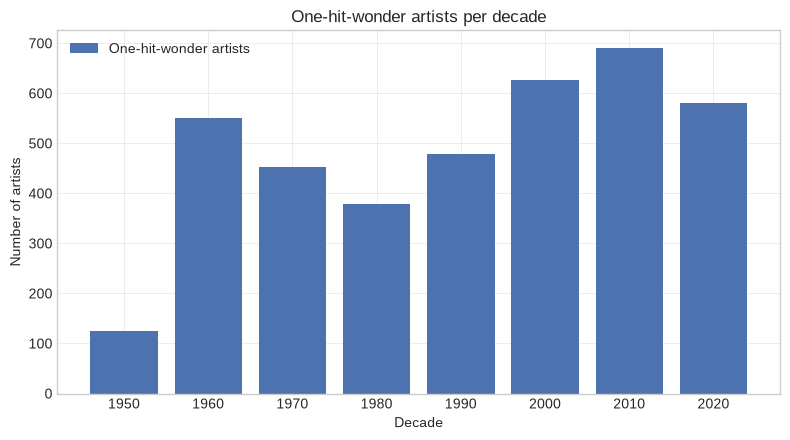

In [23]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(
    decade["Decade"].astype(str),
    decade["one_hit_wonder_artists"],
    color="#4c72b0",
    label="One-hit-wonder artists"
)

ax.set_xlabel("Decade")
ax.set_ylabel("Number of artists")
ax.set_title("One-hit-wonder artists per decade")
ax.legend()

plt.tight_layout()
plt.show()